In [1]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import numpy as np

import networkx as nx

from pathlib import Path
import os

from enum import Enum

from fame import *

import plotly.express as px
from matplotlib.pyplot import cm

# import random


In [2]:
R_earth_km = 6371


In [3]:
# Gemini-generated

# Space-Track Credentials
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')


In [4]:
tle_file_name_json = "all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [5]:
tle_file_name_txt = "all_tles_20260130.txt"


In [6]:
# planet_satellites = []
# 14-19 decayed

instrument_types = [InstrumentType.RGB, InstrumentType.HYPERSPECTRAL, InstrumentType.SAR]

swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}

skysat_satellites = [
    Satellite("SKYSAT-A", Orbital("SKYSAT 1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-B", Orbital("SKYSAT 2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2", Orbital("SKYSAT C2", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C3", Orbital("SKYSAT C3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C4", Orbital("SKYSAT C4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C5", Orbital("SKYSAT C5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C6", Orbital("SKYSAT C6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C7", Orbital("SKYSAT C7", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C8", Orbital("SKYSAT C8", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C9", Orbital("SKYSAT C9", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
]
pelican_satellites = [
    Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-300A", Orbital("PELICAN-3", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-300B", Orbital("PELICAN-4", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-5", Orbital("PELICAN-5", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-6", Orbital("PELICAN-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),

]
tanager_satellites = [
    Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instruments=[InstrumentType.HYPERSPECTRAL]),
]
# 1-6 and 8 decayed
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
]
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instruments=[InstrumentType.SAR]),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB])]
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB])]
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),]
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),   
]

for sat in skysat_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in pelican_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }
for sat in tanager_satellites:
    sat.isl_links = {s: 250 for s in skysat_satellites+pelican_satellites+tanager_satellites if s!=sat }

for sat in umbra_satellites:
    sat.isl_links = {s: 250 for s in umbra_satellites if s!=sat }

for sat in capella_acadia_satellites:
    sat.isl_links = {s: 250 for s in capella_acadia_satellites if s!=sat }

for sat in aerospace_corp_satellites:
    sat.isl_links = {s: 250 for s in aerospace_corp_satellites if s!=sat }


In [7]:
all_satellites = skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites

In [8]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {InstrumentType.RGB: _fov}

In [9]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "midnightblue"
    if "PELICAN" in sat_name:
        return "mediumblue"
    if "TANAGER" in sat_name:
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name:
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "darkorange"
    # 
    if "LOFT" in sat_name:
        return "forestgreen"
    #
    if "Ubotica" in sat_name:
        return "lime"
    #
    if "Mission Control" in sat_name:
        return "orchid"
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name:
        return "blue"
    # Black
    if "UMBRA" in constellation_name:
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name:
        return "darkorange"
    # 
    if "LOFT" in constellation_name:
        return "forestgreen"
    #
    if "Ubotica" in constellation_name:
        return "lime"
    #
    if "Mission Control" in constellation_name:
        return "orchid"
    return "red"

def satmarkerer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "p"
    if "PELICAN" in sat_name:
        return "p"
    if "TANAGER" in sat_name:
        return "p"
    # Black
    if "UMBRA" in sat_name:
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "D"
    # 
    if "LOFT" in sat_name:
        return "p"
    #
    if "Ubotica" in sat_name:
        return "p"
    #
    if "Mission Control" in sat_name:
        return "p"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}

constcolor = {sat.name: satmarkerer(sat.name) for sat in all_satellites}


In [10]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

## Let's now look at communication opportunities

In [11]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

In [12]:
min_time=dt.datetime.now(dt.timezone.utc)
max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)

# A graph-theoretical scheduler that accounts for communications

In [13]:
comm_opportunities_by_sat_and_station, comm_opportunities_by_sat = find_contact_opportunities(
    ground_stations=ground_stations,
    satellites=all_satellites,
    min_time=min_time,
    max_time=max_time,
    passes_error_s=60,
    passes_horizon_deg=45
)

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  return utc_time.astype("datetime64[ns]")
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)


In [14]:
isl_links = find_isl_opportunities(all_satellites, min_time, max_time)
isl_links

[ISL link from SKYSAT-A to SKYSAT-C1 at 2026-04-22 16:57:31.268129+00:00,
 ISL link from SKYSAT-C1 to SKYSAT-A at 2026-04-22 16:57:31.268129+00:00,
 ISL link from SKYSAT-A to SKYSAT-C1 at 2026-04-22 16:58:31.268129+00:00,
 ISL link from SKYSAT-A to PELICAN-3009 at 2026-04-22 16:58:31.268129+00:00,
 ISL link from SKYSAT-C1 to SKYSAT-A at 2026-04-22 16:58:31.268129+00:00,
 ISL link from SKYSAT-C1 to PELICAN-3009 at 2026-04-22 16:58:31.268129+00:00,
 ISL link from PELICAN-3009 to SKYSAT-A at 2026-04-22 16:58:31.268129+00:00,
 ISL link from PELICAN-3009 to SKYSAT-C1 at 2026-04-22 16:58:31.268129+00:00,
 ISL link from SKYSAT-A to SKYSAT-C1 at 2026-04-22 16:59:31.268129+00:00,
 ISL link from SKYSAT-C1 to SKYSAT-A at 2026-04-22 16:59:31.268129+00:00,
 ISL link from SKYSAT-A to SKYSAT-C1 at 2026-04-22 17:00:31.268129+00:00,
 ISL link from SKYSAT-C1 to SKYSAT-A at 2026-04-22 17:00:31.268129+00:00,
 ISL link from SKYSAT-C4 to SKYSAT-C13 at 2026-04-22 17:21:31.268129+00:00,
 ISL link from SKYSAT-

In [15]:
# So it looks like nx-temporal loses track of times when unrolling the graph.
# What we would like is:
# - Build an unrolled temporal graph from the events.
#   - Make a list of all time steps
#   - Create copies of nodes for each time step
#   - Create edges between the same node at subsequent time steps
#   - Create edges between different nodes according to contact graph, ISL links
#   - ADD WEIGHTS TO EDGES corresponding to the duration of that edge
#   - For shortest time: add edges from all copies of a node to node_EARLIEST with cost 0.

In [16]:
contact_graph, contact_graph_times = build_unrolled_temporal_graph(comm_opportunities_by_sat, isl_links)
print(contact_graph)

DiGraph with 84366 nodes and 470911 edges


In [17]:
# _path = nx.shortest_path(
#     contact_graph,
#     source='KSAT Svalbard_1772155731.586991',
#     # source='PELICAN-6_1772155731.586991',
#     target='KSAT Svalbard_EARLIEST_OUT',
#     weight=duration
#     )
# print(_path)

In [18]:
# nx.shortest_path(
#     contact_graph,
#     source='KSAT Svalbard_1772155731.586991',
#     # source='PELICAN-6_1772155731.586991',
#     target="PELICAN-6_1772328524.397859",
#     weight=duration
#     )

# shortest_path_between_stations(ground_stations[-1], pelican_satellites[-1], start_time= min_time, contact_graph=contact_graph, contact_graph_times=contact_graph_times)

In [19]:
shortest_path_between_stations(pelican_satellites[0].name, pelican_satellites[-1].name, start_time= min_time, contact_graph=contact_graph, contact_graph_times=contact_graph_times)

([{'station': PELICAN-3001,
   'station_type': 'satellite',
   'time': datetime.datetime(2026, 4, 22, 16, 31, 23, 566398, tzinfo=datetime.timezone.utc)},
  {'station': PELICAN-3001,
   'station_type': 'satellite',
   'time': datetime.datetime(2026, 4, 22, 17, 0, 52, 909398, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Singapore | Lon 103.9915°, lat 1.3661°, alt 0 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 4, 22, 17, 0, 52, 909398, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Svalbard | Lon 15.39964°, lat 78.22875°, alt 0 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 4, 22, 17, 0, 52, 909398, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Svalbard | Lon 15.39964°, lat 78.22875°, alt 0 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 4, 22, 17, 32, 3, 92073, tzinfo=datetime.timezone.utc)},
  {'station': PELICAN-6,
   'station_type': 'satellite',
   'time': 

In [20]:
# _path = nx.shortest_path(
#     contact_graph,
#     source=f'KSAT Svalbard_{min_time.timestamp()}',
#     # source='PELICAN-6_1772155731.586991',
#     target="PELICAN-6_EARLIEST_OUT",
#     weight=lambda s, t, edge: edge['duration'].total_seconds()
#     )
# print(_path)

In [21]:
_sp, _ = shortest_path_between_stations(pelican_satellites[0], mission_control_satellites[-1], start_time= min_time, contact_graph=contact_graph, contact_graph_times=contact_graph_times)
print(_sp)

[{'station': PELICAN-3001, 'station_type': 'satellite', 'time': datetime.datetime(2026, 4, 22, 16, 31, 23, 566398, tzinfo=datetime.timezone.utc)}, {'station': PELICAN-3001, 'station_type': 'satellite', 'time': datetime.datetime(2026, 4, 22, 17, 0, 52, 909398, tzinfo=datetime.timezone.utc)}, {'station': Location KSAT Singapore | Lon 103.9915°, lat 1.3661°, alt 0 km, 'station_type': 'ground_station', 'time': datetime.datetime(2026, 4, 22, 17, 0, 52, 909398, tzinfo=datetime.timezone.utc)}, {'station': Location KSAT Punta Arenas | Lon -70.85021°, lat -52.93279°, alt 0 km, 'station_type': 'ground_station', 'time': datetime.datetime(2026, 4, 22, 17, 0, 52, 909398, tzinfo=datetime.timezone.utc)}, {'station': Location KSAT Punta Arenas | Lon -70.85021°, lat -52.93279°, alt 0 km, 'station_type': 'ground_station', 'time': datetime.datetime(2026, 4, 22, 17, 15, 24, 15563, tzinfo=datetime.timezone.utc)}, {'station': Mission Control Persistence, 'station_type': 'satellite', 'time': datetime.datetim

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)


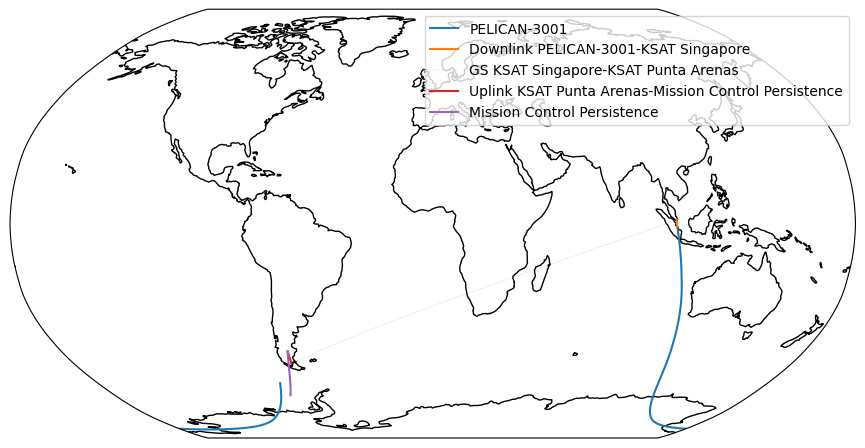

In [22]:
plot_shortest_path_between_stations(_sp)

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)


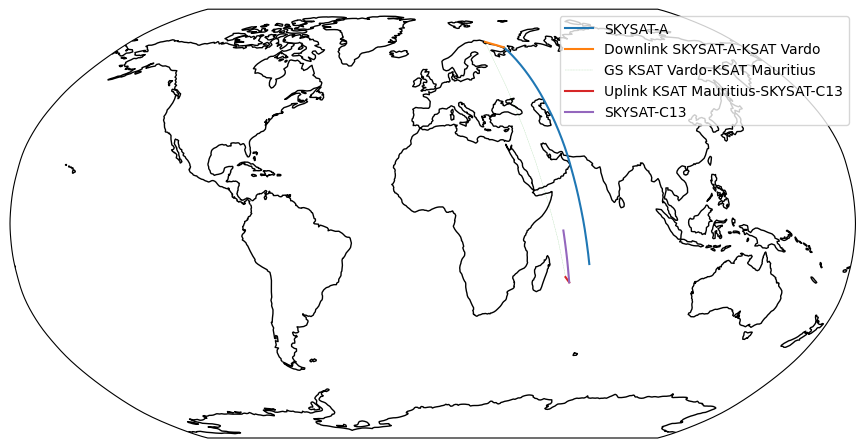

In [23]:
_sp, _ = shortest_path_between_stations(skysat_satellites[0], skysat_satellites[-1], start_time= min_time, contact_graph=contact_graph, contact_graph_times=contact_graph_times)
plot_shortest_path_between_stations(_sp)

In [24]:
def find_nodes_closest_to_time(station, desired_time: dt.datetime, contact_graph_times: list):

    insert_index = bisect.bisect(contact_graph_times, desired_time)
    if insert_index == len(contact_graph_times):
        # Last entry, so there is no node after that
        # return ValueError("Node is after end time for contact graph")
        closest_time_post = None
        node_name_post = None
    else: 
        closest_time_post = contact_graph_times[insert_index]
        node_name_post = f"{station.name}_{closest_time_post.timestamp()}"
    if insert_index == 0:
        # First entry, so there is no node before that
        closest_time_pre = None
        node_name_pre = None
        # return ValueError("Node is before start time for contact graph")
    else:
        closest_time_pre = contact_graph_times[insert_index-1]
        node_name_pre = f"{station.name}_{closest_time_pre.timestamp()}"

    return (node_name_pre, node_name_post)

In [25]:
def schedule_request_on_contact_graph(
        request: ObservationRequest,
        current_time: dt.datetime,
        satellites,
        contact_graph,
        contact_graph_times,
        current_planner_node,
        data_sink_node
        ):
    
    # Find ObservationOpportunity list
    print("Finding obs opportunities")
    opportunities = find_observation_opportunities(observation_requests=[request], satellites=satellites)
    if len(opportunities) == 0:
        # TODO error handling
        return None, None
    
    passes = opportunities[request]

    # Make a copy of the contact graph
    # planning_graph = copy.deepcopy(contact_graph)

    # planning_graph_pre = copy_contact_graph(contact_graph, node_prefix="PRE_")
    # planning_graph_post = copy_contact_graph(contact_graph, node_prefix="POST_")
    prefix_pre_obs =  'PRE_'
    prefix_post_obs = 'POST_'

    print("Building extended graph")
    planning_graph = nx.union(contact_graph, contact_graph, rename=(prefix_pre_obs, prefix_post_obs))

    planning_graph.add_node("DATA_SINK")
        
    # Annotate the contact graph with rewards corresponding to the observation on the right edges
    for edge in planning_graph.edges():
        planning_graph.edges[edge]['inverse_quality'] = 0

    print("Adding observation edges")
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            obspass = satpass.highest
            _quality = observation_quality(obspass)

            # Recall that:
            # - You want to minimize cost
            # - You start on the PRE side
            # - You end on the POST side
            # - Only edges that go PRE to POST are costly
            # - So minimize cost=traverse at the lowest-cost edge 

            # Find the edge corresponding to satellite satellite at time satpass.highest.time
            (node_name_before, node_name_after) = find_nodes_closest_to_time(satellite, obspass.time, contact_graph_times)
            # What if this observation is before any communication? Then the upstream node will be None
            # Or what if the observation is after any communication? Then the downstream node will be None
            # In both cases, the observation is not useful (either we can't dispatch it in time, or we can't get the data in time).
            # So we skip it
            if (node_name_before is not None and node_name_after is not None):
                # Modify the contact graph so we exit after one request is fulfilled, adding a sink node and removing others
                planning_graph.add_edge(
                    prefix_pre_obs+node_name_before,
                    prefix_post_obs+node_name_after,
                    time=contact_graph.edges[node_name_before, node_name_after]['time'],
                    duration=contact_graph.edges[node_name_before, node_name_after]['duration'],
                    source_station=contact_graph.edges[node_name_before, node_name_after]['source_station'],
                    target_station=contact_graph.edges[node_name_before, node_name_after]['target_station'],
                    source_station_type=contact_graph.edges[node_name_before, node_name_after]['source_station_type'],
                    target_station_type=contact_graph.edges[node_name_before, node_name_after]['target_station_type'],
                    inverse_quality=1./_quality,
                    observation=obspass,
                    )

    source_station = prefix_pre_obs+current_planner_node.name

    target_station = prefix_post_obs+data_sink_node.name
    
    print("Searching")
    # Shortest path!
    abbreviated_path, _path = shortest_path_between_stations(
        source_station,
        target_station,
        start_time=current_time,
        contact_graph=planning_graph,
        contact_graph_times=contact_graph_times,
        edge_cost=lambda s, t, edge: edge['inverse_quality']
        )
    
    # Now what was the observation we picked?
    observations = []
    for node_index in range(len(_path)-1):
        # _edge = (_path[node_index], _path[node_index+1])
        if 'observation' in planning_graph.edges[_path[node_index], _path[node_index+1]].keys():
            _observation = planning_graph.edges[_path[node_index], _path[node_index+1]]['observation']
            _satellite = planning_graph.edges[_path[node_index], _path[node_index+1]]['source_station']
            observations.append((_satellite, _observation))

    return observations, abbreviated_path, _path

    # TODO Report (i) observation opportunity and (ii) full uplink and downlink path

In [26]:
obs_request = ObservationRequest(
    Rotterdam.lon_deg,
    Rotterdam.lat_deg,
    min_time=min_time,
    max_time=max_time,
    alt_km=Rotterdam.alt_km,
    request_name="Test request in Rotterdam",
    min_elevation_deg=45,
    instrument=InstrumentType.RGB
    )

schedule_request_on_contact_graph(
    obs_request,
    current_time=min_time,
    satellites=all_satellites,
    contact_graph=contact_graph,
    contact_graph_times=contact_graph_times,
    current_planner_node=ground_stations[0],
    data_sink_node=ground_stations[0]
    )

/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  return utc_time.astype("datetime64[ns]")
/Users/frossi/.local/share/mamba/envs/aig-fame/lib/python3.13/site-packages/pyorbital/__init__.py:28: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.datetime64(utc_time)


Finding obs opportunities
Building extended graph
Adding observation edges
Searching


([(PELICAN-3001,
   Observation  at 2026-04-22 23:16:14.789218+00:00 by PELICAN-3001 with InstrumentType.RGB. Look angle 258.45814910214966 | 53.77311957847028 az/dec deg, zenith angle 115.27981028989765 deg, range 374.81470436038006 km, duration 0:01:00)],
 [{'station': Location KSAT Panama | Lon -79.55°, lat 8.9833°, alt 0.028 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 4, 22, 16, 31, 23, 566398, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Panama | Lon -79.55°, lat 8.9833°, alt 0.028 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 4, 22, 20, 21, 47, 599712, tzinfo=datetime.timezone.utc)},
  {'station': Location KSAT Svalbard | Lon 15.39964°, lat 78.22875°, alt 0 km,
   'station_type': 'ground_station',
   'time': datetime.datetime(2026, 4, 22, 20, 21, 47, 599712, tzinfo=datetime.timezone.utc)},
  {'station': PELICAN-3001,
   'station_type': 'satellite',
   'time': datetime.datetime(2026, 4, 22, 20, 21, 47, 59